In [2]:
import dill
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
ALL_RESULTS = dill.load(open("diss_example_gridsearch.pkl", "rb"))

In [4]:
# First column = X position
# Second column = Y position

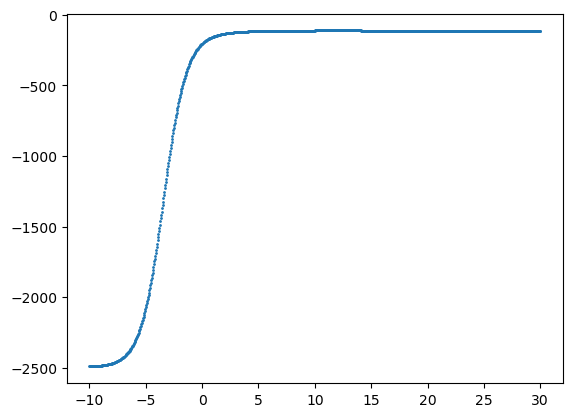

In [5]:
sfpl = lambda x:x#torch.nn.Softplus()
data = ALL_RESULTS["prod"][1]["MAP"]
plt.scatter(sfpl(data[:, 0]), data[:, 1], s=1)

0.037599999999999995
282


/tmp/ipykernel_1481219/2020801375.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  opt_loss = torch.tensor(data[:, 0] <= 6.4499, dtype=torch.bool) & torch.tensor(data[:, 1] <= 6.3617, dtype=torch.bool)
/tmp/ipykernel_1481219/2020801375.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  opt_loss = torch.tensor(data[:, 0] <= 6.4599, dtype=torch.bool) & torch.tensor(data[:, 1] <= 6.3717, dtype=torch.bool)


tensor([[   5.4709,    6.3527, -113.1966],
        [   5.5511,    6.2725, -113.1960],
        [   5.5511,    6.3527, -113.1916],
        [   5.6313,    6.1924, -113.1955],
        [   5.6313,    6.2725, -113.1910],
        [   5.6313,    6.3527, -113.1871],
        [   5.7114,    6.1122, -113.1951],
        [   5.7114,    6.1924, -113.1906],
        [   5.7114,    6.2725, -113.1866],
        [   5.7114,    6.3527, -113.1830],
        [   5.7916,    5.9519, -113.1999],
        [   5.7916,    6.0321, -113.1949],
        [   5.7916,    6.1122, -113.1903],
        [   5.7916,    6.1924, -113.1862],
        [   5.7916,    6.2725, -113.1826],
        [   5.7916,    6.3527, -113.1794],
        [   5.8717,    5.8717, -113.1999],
        [   5.8717,    5.9519, -113.1948],
        [   5.8717,    6.0321, -113.1901],
        [   5.8717,    6.1122, -113.1859],
        [   5.8717,    6.1924, -113.1822],
        [   5.8717,    6.2725, -113.1790],
        [   5.8717,    6.3527, -113.1762],
        [  

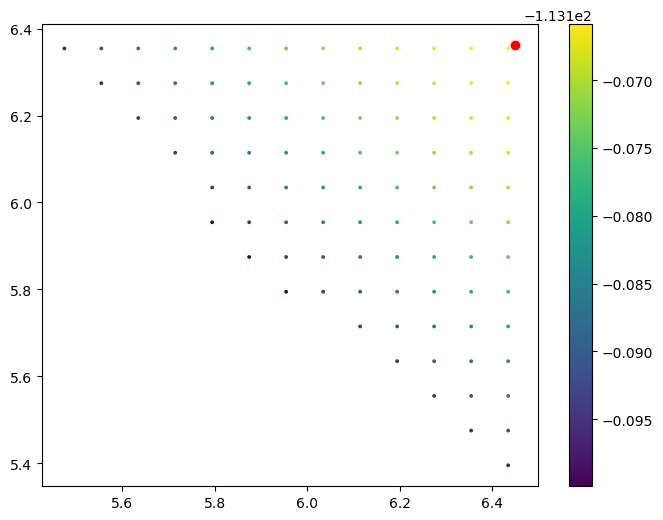

In [47]:
sfpl = torch.nn.Softplus()
data = ALL_RESULTS["sum"][2]["MAP"]
total_entries = data.numel()
t = -113.2
mask = data[:, 2] >= t
data = data[mask]
opt_loss = torch.tensor(data[:, 0] <= 6.4499, dtype=torch.bool) & torch.tensor(data[:, 1] <= 6.3617, dtype=torch.bool)
data = data[opt_loss]
print(data.numel()/total_entries*100)
print(data.numel())

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
lik_surface = ax.scatter(sfpl(data[:,0]), sfpl(data[:, 1]), c=data[:,2], s=3, cmap="viridis")
x1, y1 = [-7, -7], [-10, 30]
#plt.plot(x1, y1, color="red")
#plt.plot(y1, x1, color="red")
# Optimum according to training: [tensor(6.4499), tensor(6.3617)]
ax.scatter(6.4499, 6.3617, color="red")

fig.colorbar(lik_surface)
opt_loss = torch.tensor(data[:, 0] <= 6.4599, dtype=torch.bool) & torch.tensor(data[:, 1] <= 6.3717, dtype=torch.bool)
data[opt_loss]

In [7]:
# Small and easy code to verify that torch.stack or torch.prod/sum produces the differing gradients
import torch
import torch.nn as nn

class ToyModel(nn.Module):
    def __init__(self, num_sigmas):
        super().__init__()
        self.num_sigmas = num_sigmas

        for i in range(num_sigmas):
            raw = nn.Parameter(torch.tensor(0.0))
            self.register_parameter(f"raw_n_num_scale_{i}", raw)

            # simple positive constraint via exp
            setattr(self, f"raw_n_num_scale_{i}_constraint", torch.nn.functional.softplus)

    @property
    def n_num_scales(self):
        sigmas = []
        for i in range(self.num_sigmas):
            raw = getattr(self, f"raw_n_num_scale_{i}")
            constraint = getattr(self, f"raw_n_num_scale_{i}_constraint")
            sigmas.append(constraint(raw))
        return torch.stack(sigmas)

    def forward(self, x):
        scale = self.n_num_scales.prod()
        return scale * x


# test
model = ToyModel(4)
x = torch.ones(5)
y = torch.ones(5)*8

print(model.n_num_scales)   # <-- should work
print(model(x))
print(y)


tensor([0.6931, 0.6931, 0.6931, 0.6931], grad_fn=<StackBackward0>)
tensor([0.2308, 0.2308, 0.2308, 0.2308, 0.2308], grad_fn=<MulBackward0>)
tensor([8., 8., 8., 8., 8.])


In [8]:
import torch
import torch.nn as nn

from pygranso.pygranso import pygranso
from pygranso.pygransoStruct import pygransoStruct

torch.manual_seed(0)

class ToyModel(nn.Module):
    def __init__(self, num_sigmas: int):
        super().__init__()
        self.num_sigmas = num_sigmas

        # Raw unconstrained parameters (scalar each)
        for i in range(num_sigmas):
            self.register_parameter(f"raw_n_num_scale_{i}", nn.Parameter(torch.tensor(0.0)))

            # A simple "positive constraint" via exp (like a constraint.transform(raw))
            setattr(self, f"raw_n_num_scale_{i}_constraint", torch.nn.Softplus())

    @property
    def n_num_scales(self):
        sigmas = []
        for i in range(self.num_sigmas):
            raw = getattr(self, f"raw_n_num_scale_{i}")
            constraint = getattr(self, f"raw_n_num_scale_{i}_constraint")
            sigmas.append(constraint(raw))
        return torch.stack(sigmas)  # shape: (num_sigmas,)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        scale = self.n_num_scales.sum()
        return scale * x


# ----------------------
# Data (x are labels/features, y are targets)
# ----------------------
device = torch.device("cpu")
dtype = torch.double

#x = torch.linspace(-1, 1, 50, device=device, dtype=dtype)
x = torch.ones(1)
true_scale = torch.tensor(10.0, device=device, dtype=dtype)
y = true_scale * x
print(y)
model = ToyModel(num_sigmas=2).to(device=device, dtype=dtype)

# ----------------------
# PyGRANSO combined function
# ----------------------
def user_fn(model: nn.Module, x: torch.Tensor, y: torch.Tensor):
    pred = model(x)
    f = torch.mean((pred - y) ** 2)  # objective

    ci = None  # no inequality constraints
    ce = None  # no equality constraints
    return [f, ci, ce]

comb_fn = lambda mdl: user_fn(mdl, x, y)

# ----------------------
# PyGRANSO options
# ----------------------
opts = pygransoStruct()
opts.torch_device = device
opts.maxit = 1000
opts.print_frequency = 10

# IMPORTANT: x0 must be a column vector (nvar, 1), commonly built from module parameters
x0 = torch.nn.utils.parameters_to_vector(model.parameters()).detach().reshape(-1, 1)
opts.x0 = x0

# ----------------------
# Run PyGRANSO
# ----------------------
soln = pygranso(var_spec=model, combined_fn=comb_fn, user_opts=opts)

# After solve, the solution vector is in soln.final.x (a column vector).
# Depending on your PyGRANSO version/setup, you may need to manually load it back into the model.
# If your installation doesn’t auto-update module parameters, do:
with torch.no_grad():
    vec = soln.final.x.detach().reshape(-1)
    torch.nn.utils.vector_to_parameters(vec, model.parameters())

print("final constrained scales:", model.n_num_scales.detach().cpu().numpy())
print("final scale(prod):", model.n_num_scales.sum().item())


tensor([10.])


╔═════ QP SOLVER NOTICE ════════════════════════════════════════════════════════════════════════╗
║  PyGRANSO requires a quadratic program (QP) solver that has a quadprog-compatible interface,  ║
║  the default is osqp. Users may provide their own wrapper for the QP solver.                  ║
║  To disable this notice, set opts.quadprog_info_msg = False                                   ║
╚═══════════════════════════════════════════════════════════════════════════════════════════════╝
══════════════════════════════════════════════════════════════════════════════════════════════╗
PyGRANSO: A PyTorch-enabled port of GRANSO with auto-differentiation                          ║ 
Version 1.2.0                                                                                 ║ 
Licensed under the AGPLv3, Copyright (C) 2021-2022 Tim Mitchell and Buyun Liang               ║ 
══════════════════════════════════════════════════════════════════════════════════════════════╣
Problem spe

In [2]:
from helpers.plotting_functions import plot_3d_gp, plot_3d_data, plot_single_input_gp_posterior
from helpers.util_functions import prior_distribution, reparameterize_model_full, reparameterize_model_trainable, log_normalized_prior, extract_trainable_model_parameters
from laplace_model_selection.metrics import Lap0, LapAIC, LapBIC, AIC, BIC, NestedSampling, MLL, MAP
from helpers.training_functions import granso_optimization
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import torch
import gpytorch
torch.set_default_dtype(torch.float64)

import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import dill
import copy

# %%
X = torch.linspace(0, 10, 100)
y = torch.linspace(0, 10, 100)


base_kernel_parameter_priors = {
    ("RBFKernel", "lengthscale"): {"mean": 0.0, "std": 10.0}, 
    ("MaternKernel", "lengthscale"): {"mean": 0.0, "std": 10.0},
    ("LinearKernel", "variance"): {"mean": 0.0, "std": 10.0},
    ("AffineKernel", "variance"): {"mean": 0.0, "std": 10.0},
    ("RQKernel", "lengthscale"): {"mean": 0.0, "std": 10.0},
    ("RQKernel", "alpha"): {"mean": 0.0, "std": 10.0},
    ("CosineKernel", "period_length"): {"mean": 0.0, "std": 10.0},
    ("PeriodicKernel", "lengthscale"): {"mean": 0.0, "std": 10.0},
    ("PeriodicKernel", "period_length"): {"mean": 0.0, "std": 10.0},
    ("ScaleKernel", "outputscale"): {"mean": 0.0, "std": 10.0},
    ("NSumCSEKernel", "n_sum_scale"): {"mean": 0.0, "std": 10.0},
    ("LODE_Kernel", "signal_variance_2_0"): {"mean": 0.0, "std": 10.0},  # full match
    ("LODE_Kernel", "lengthscale"): {"mean": 0.0, "std": 10.0},           # base fallback
}


base_parameter_priors = {
    "likelihood.raw_task_noises": {"mean": 0.0, "std": 10.0},
    "likelihood.raw_noise": {"mean": 0.0, "std": 10.0}
}


base_kernel_param_specs = {
    ("RBFKernel", "lengthscale"): {"bounds": (-1.0, 10.0), "type":"uniform"}, # add ', "type": "uniform"},' # to use uniform distribution
    ("MaternKernel", "lengthscale"): {"bounds": (-1.0, 10.0), "type":"uniform"},
    ("LinearKernel", "variance"): {"bounds": (1e-1, 1.0)},
    ("AffineKernel", "variance"): {"bounds": (1e-1, 1.0)},
    ("RQKernel", "lengthscale"): {"bounds": (-1.0, 10.0), "type":"uniform"},
    ("RQKernel", "alpha"): {"bounds": (1e-1, 10.0), "type":"uniform"},
    ("CosineKernel", "period_length"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    #("PeriodicKernel", "lengthscale"): {"bounds": (1e-1, 5.0)},
    #("PeriodicKernel", "period_length"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    ("PeriodicKernel", "period_length"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    ("ScaleKernel", "outputscale"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    ("NSumCSEKernel", "n_sum_scale"): {"bounds": (-1.0, 10.0), "type": "uniform"},
    #("LODE_Kernel", "signal_variance_2_0"): {"bounds": (0.05, 0.5)},  # full match
    ("LODE_Kernel", "signal_variance"): {"bounds": (1e-1, 10)},  # base
    ("LODE_Kernel", "lengthscale"): {"bounds": (1e-1, 5.0)},           
}


base_param_specs = {
    "likelihood.raw_task_noises": {"bounds": (1e-1, 1e-0)},
    "likelihood.raw_noise": {"bounds": (1e-0, 1e+1), "type":"uniform"}
}

# %%
from helpers.example_kernels import _c_se, _se
import torch
import gpytorch


#class NSumCSEKernel(gpytorch.kernels.Kernel):
#    """
#    k(x, x') = (sum_i sigma_i) * SE(x, x')
#    with fixed SE lengthscale = 1.
#    """
#    def __init__(self, num_c=1, active_dims=None):
#        super().__init__(active_dims=active_dims)
#
#        # Base SE (RBF) kernel
#        self.base_kernel = gpytorch.kernels.RBFKernel(active_dims=active_dims)
#
#        # Fix lengthscale to 1.0 and disable gradient
#        self.base_kernel.lengthscale = 1.0
#        self.base_kernel.raw_lengthscale.requires_grad_(False)
#
#        # Parameters sigma_i (we’ll constrain them positive)
#        self.register_parameter(
#            name="raw_n_sum_scale",
#            parameter=torch.nn.Parameter(torch.zeros(num_c))
#        )
#        self.register_constraint("raw_n_sum_scale", gpytorch.constraints.Positive())
#        self.num_sigmas = num_c
#
#    def forward(self, x1, x2, diag=False, **params):
#        # Compute base SE covariance
#        base_covar = self.base_kernel(x1, x2, diag=diag, **params)
#
#        # Transform to constrained space
#        sigma = self.raw_n_sum_scale_constraint.transform(self.raw_n_sum_scale)
#
#        # Sum over all sigma_i
#        scale = sigma.sum()
#
#        # Scale the covariance
#        return base_covar.mul(scale)



class NSumCSEKernel(gpytorch.kernels.Kernel):
    """
    k(x, x') = (sum_i sigma_i) * SE(x, x')
    with fixed SE lengthscale = 1.
    """
    def __init__(self, num_c: int = 1, active_dims=None):
        super().__init__(active_dims=active_dims)

        # Base SE (RBF) kernel
        self.base_kernel = gpytorch.kernels.RBFKernel(active_dims=active_dims)

        # Fix lengthscale to 1.0 and disable gradient
        self.base_kernel.lengthscale = 1.0
        self.base_kernel.raw_lengthscale.requires_grad_(False)

        self.num_sigmas = num_c

        # Register each sigma_i as its own parameter with its own constraint
        for i in range(num_c):
            self.register_parameter(
                name=f"raw_n_sum_scale_{i}",
                parameter=torch.nn.Parameter(torch.zeros(()))  # scalar parameter
            )
            self.register_constraint(
                f"raw_n_sum_scale_{i}",
                gpytorch.constraints.Positive()
            )

    @property
    def n_sum_scales(self):
        """
        Returns a tensor of constrained sigma_i of shape (num_c,).
        """
        sigmas = []
        for i in range(self.num_sigmas):
            raw = getattr(self, f"raw_n_sum_scale_{i}")
            constraint = getattr(self, f"raw_n_sum_scale_{i}_constraint")
            sigmas.append(constraint.transform(raw))
        return torch.stack(sigmas)

    def forward(self, x1, x2, diag: bool = False, **params):
        # Base SE covariance
        base_covar = self.base_kernel(x1, x2, diag=diag, **params)

        # Sum over all constrained sigma_i
        scale = self.n_sum_scales.sum()

        # Scale the covariance
        return base_covar.mul(scale)



class NNumCSEKernel(gpytorch.kernels.Kernel):
    """
    k(x, x') = (sum_i sigma_i) * SE(x, x')
    with fixed SE lengthscale = 1.
    """
    def __init__(self, num_c: int = 1, active_dims=None):
        super().__init__(active_dims=active_dims)

        # Base SE (RBF) kernel
        self.base_kernel = gpytorch.kernels.RBFKernel(active_dims=active_dims)

        # Fix lengthscale to 1.0 and disable gradient
        self.base_kernel.lengthscale = 1.0
        self.base_kernel.raw_lengthscale.requires_grad_(False)

        self.num_sigmas = num_c

        # Register each sigma_i as its own parameter with its own constraint
        for i in range(num_c):
            self.register_parameter(
                name=f"raw_n_num_scale_{i}",
                parameter=torch.nn.Parameter(torch.zeros(()))  # scalar parameter
            )
            self.register_constraint(
                f"raw_n_num_scale_{i}",
                gpytorch.constraints.Positive()
            )

    @property
    def n_num_scales(self):
        """
        Returns a tensor of constrained sigma_i of shape (num_c,).
        """
        sigmas = []
        for i in range(self.num_sigmas):
            raw = getattr(self, f"raw_n_num_scale_{i}")
            constraint = getattr(self, f"raw_n_num_scale_{i}_constraint")
            sigmas.append(constraint.transform(raw))
        return torch.stack(sigmas)

    def forward(self, x1, x2, diag: bool = False, **params):
        # Base SE covariance
        base_covar = self.base_kernel(x1, x2, diag=diag, **params)

        # Prod over all constrained sigma_i
        scale = self.n_num_scales.prod()

        # Scale the covariance
        return base_covar.mul(scale)

def _n_sum_c_se(*, active_dims=None, num_c=1, **_):
    return NSumCSEKernel(active_dims=active_dims, num_c=num_c)

#def _n_sum_c_se(*, active_dims=None, num_c=1, **_):
#    se_kern = _se(active_dims=active_dims)
#    se_kern.raw_lengthscale.requires_grad = False
#    se_kern.lengthscale.data = torch.tensor(1.0)
#    for k in range(0, num_c):
#        se_kern += gpytorch.kernels.ScaleKernel(se_kern)
#    return se_kern

#def _n_num_c_se(*, active_dims=None, num_c=1, **_):
#    se_kern = _se(active_dims=active_dims)
#    se_kern.raw_lengthscale.requires_grad = False
#    se_kern.lengthscale.data = torch.tensor(1.0)
#    for k in range(0, num_c):
#        se_kern = gpytorch.kernels.ScaleKernel(se_kern)
#    return se_kern

def _n_num_c_se(*, active_dims=None, num_c=1, **_):
    return NNumCSEKernel(active_dims=active_dims, num_c=num_c)

class _BaseExactGP(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood, kernel=gpytorch.kernels.RBFKernel,
                 weights=None, active_dims=None):
        super(_BaseExactGP, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = kernel

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)


def neg_loss(train_x, train_y, model, likelihood, parameter_priors, kernel_parameter_priors, model_parameter_prior, MAP=False):
        mll_fkt = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model) 
        loss = -mll_fkt(model(train_x), train_y)
        if MAP:
            log_p = log_normalized_prior(model, param_specs=parameter_priors, kernel_param_specs=kernel_parameter_priors, prior=model_parameter_prior)
            loss -= log_p


ALL_METRIC_LOGS = {}
for n in list(range(1, 16)):
    print(f"Run {n}")
    # Initialize GP model with the kernel and the data
    model_likelihood_MLL = gpytorch.likelihoods.GaussianLikelihood()
    model_MLL = _BaseExactGP(X, y, model_likelihood_MLL, kernel=_n_num_c_se(num_c=n))
    #model_MLL = _BaseExactGP(X, y, model_likelihood_MLL, kernel=_n_sum_c_se(num_c=n))
    #model_likelihood_MLL.noise.data = torch.tensor(0.0)
    model_likelihood_MLL.raw_noise.requires_grad = False

    model_likelihood_MAP = gpytorch.likelihoods.GaussianLikelihood()
    model_MAP = _BaseExactGP(X, y, model_likelihood_MAP, kernel=_n_num_c_se(num_c=n))
    #model_MAP = _BaseExactGP(X, y, model_likelihood_MAP, kernel=_n_sum_c_se(num_c=n))
    #model_likelihood_MAP.noise.data = torch.tensor(0.0)
    model_likelihood_MAP.raw_noise.requires_grad = False

    # Define the prior distribution for the model parameters
    model_parameter_prior = prior_distribution(model_MAP, param_specs=None, kernel_param_specs=None, default_mean=0.0, default_std=10.0)

    # Train the GP using GRANSO
    neg_scaled_map, model_MAP, model_likelihood_MAP, training_log_MAP = granso_optimization(model_MAP, model_likelihood_MAP, X, y, random_restarts=1, maxit=1000, MAP=True, double_precision=False, verbose=False, model_parameter_prior=model_parameter_prior)
    pos_unscaled_map = -neg_scaled_map*len(X)

    neg_scaled_mll, model_MLL, model_likelihood_MLL, training_log_MLL = granso_optimization(model_MLL, model_likelihood_MLL, X, y, random_restarts=1, maxit=1000, MAP=False, double_precision=False, verbose=False)
    pos_unscaled_mll = -neg_scaled_mll*len(X)

    map = MAP(logarithmic=True, scaling=False)
    mll = MLL(logarithmic=True, scaling=False)
    
    map_call = lambda : map(model_MAP, model_likelihood_MAP, X, y, prior=model_parameter_prior, logging=True)
    mll_call = lambda : mll(model_MLL, model_likelihood_MLL, X, y, logging=True)

    manual_map_val = map_call()
    manual_mll_val = mll_call()
    print(f"Manual MAP: {manual_map_val[0]}\t Train MAP: {pos_unscaled_map}")
    print(f"Manual MLL: {manual_mll_val[0]}\t Train MLL: {pos_unscaled_mll}")


Run 1
Manual MAP: -110.33385214517052	 Train MAP: -110.33385214517052
Manual MLL: -106.26495891751951	 Train MLL: -106.26495891751951
Run 2
Manual MAP: -112.84889679526967	 Train MAP: -112.84889679526967
Manual MLL: -106.2649589175189	 Train MLL: -106.26495891751888
Run 3
Manual MAP: -116.0115450844324	 Train MAP: -116.01154508443234
Manual MLL: -106.2649589175189	 Train MLL: -106.26495891751885
Run 4
Manual MAP: -119.21536977081527	 Train MAP: -119.21536977081526
Manual MLL: -106.26495891751885	 Train MLL: -106.26495891751885
Run 5
Manual MAP: -122.429102974696	 Train MAP: -122.42910297469595
Manual MLL: -106.26495891751888	 Train MLL: -106.26495891751885
Run 6
Manual MAP: -125.64665801810224	 Train MAP: -125.64665801810217
Manual MLL: -106.26495891751888	 Train MLL: -106.26495891751885
Run 7
Manual MAP: -128.86607544267224	 Train MAP: -128.8660754426722
Manual MLL: -106.26495891751885	 Train MLL: -106.26495891751885
Run 8
Manual MAP: -132.0865401182285	 Train MAP: -132.08654011822847